<a href="https://colab.research.google.com/github/kaushalabhinav574-rgb/sutlej-water-quality-ml/blob/main/sutlej_water_quality_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving sutlej_water_quality_dataset.csv to sutlej_water_quality_dataset.csv
   Year  Month    Location    DO    BOD     COD    pH  Temperature     TDS  \
0  2005      1    Upstream  4.81  42.88   90.52  8.16        13.12  267.00   
1  2005      1   Midstream  8.24  11.13   30.00  7.49        16.08  543.57   
2  2005      1  Downstream  5.42  35.76   31.96  8.02        21.85  184.84   
3  2005      2    Upstream  4.28   6.20   85.27  7.90        12.44  521.38   
4  2005      2   Midstream  6.10   9.95  116.65  8.44        28.79  821.12   

   Turbidity  Alkalinity  Chlorides  Sulphates  Nitrates  Ammonia  
0      16.33      313.87     154.27     143.07      1.00     4.85  
1      89.23      158.63     156.84      32.20      7.66     1.90  
2     123.47      126.04      25.61     190.03     24.16     4.06  
3      11.71      325.52      72.11     134.19      8.14     2.65  
4     121.59      328.91      31.24      43.22      1.61     1.69  
          WQI
0  372.663719
1  327.459500
2  50

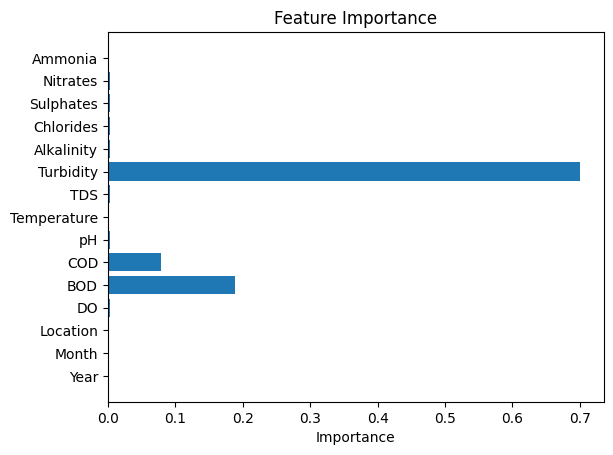

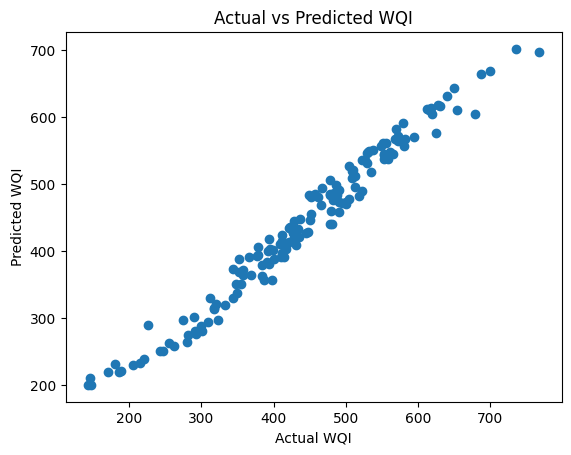

In [1]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 2. LOAD DATASET
# Upload CSV file in Colab
from google.colab import files
uploaded = files.upload()

# Load file
df = pd.read_csv("sutlej_water_quality_dataset.csv")

print(df.head())

# ===============================
# 3. HANDLE DATA
# ===============================
df = df.dropna()

# Encode Location (categorical → numeric)
df["Location"] = df["Location"].map({
    "Upstream": 0,
    "Midstream": 1,
    "Downstream": 2
})

# ===============================
# 4. CALCULATE WQI (BROWN METHOD)
# ===============================

# Standard permissible values (approx WHO/ISI)
standards = {
    "DO": 5,
    "BOD": 3,
    "COD": 10,
    "pH": 7,
    "TDS": 500,
    "Nitrates": 10,
    "Turbidity": 5,
    "Temperature": 25
}

# Weights
weights = {
    "DO": 0.17,
    "BOD": 0.11,
    "COD": 0.10,
    "pH": 0.11,
    "TDS": 0.07,
    "Nitrates": 0.10,
    "Turbidity": 0.08,
    "Temperature": 0.10
}

def calculate_wqi(row):
    total = 0
    weight_sum = 0

    for param in weights:
        qi = (row[param] / standards[param]) * 100
        wi = weights[param]

        total += qi * wi
        weight_sum += wi

    return total / weight_sum

df["WQI"] = df.apply(calculate_wqi, axis=1)

print(df[["WQI"]].head())

# ===============================
# 5. FEATURE SELECTION
# ===============================
X = df.drop(columns=["WQI"])
y = df["WQI"]

# ===============================
# 6. TRAIN TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 7. RANDOM FOREST MODEL
# ===============================
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ===============================
# 8. PREDICTION
# ===============================
y_pred = model.predict(X_test)

# ===============================
# 9. EVALUATION
# ===============================
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

# ===============================
# 10. FEATURE IMPORTANCE
# ===============================
importances = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

# ===============================
# 11. ACTUAL vs PREDICTED
# ===============================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual WQI")
plt.ylabel("Predicted WQI")
plt.title("Actual vs Predicted WQI")
plt.show()